# RDKit: substructure queries using SMARTS

This notebook uses **SMARTS** patterns to search molecules for substructures, such as functional groups or ring systems, and uses RDKit's drawing tools to highlight the matches.

By the end you should be able to:

- explain the difference between SMILES and SMARTS
- write simple SMARTS patterns for common functional groups
- check whether a molecule contains a pattern, find where, and count how many times
- search a file of approved drugs for a pattern

Cells marked **Exercise** are for you to try. A hidden solution follows each one - click "Solution" to show it, but have a go first!

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

# uncomment this if the images look low quality
# IPythonConsole.ipython_useSVG=True

# 1. SMILES vs SMARTS

In notebook 1 we used SMILES to describe one specific molecule. SMARTS looks very similar, but describes a **pattern**. One SMARTS pattern can match part of many different molecules.

For example, the SMILES `CCO` is ethanol, while the SMARTS `[OH]` means "an oxygen with one hydrogen", which appears in lots of molecules.

We create a pattern with `Chem.MolFromSmarts()` and check whether a molecule contains it with `HasSubstructMatch()`:

In [2]:
ethanol = Chem.MolFromSmiles('CCO')
hydroxyl = Chem.MolFromSmarts('[OH]')

ethanol.HasSubstructMatch(hydroxyl)

True

Some useful SMARTS building blocks:

| SMARTS | Meaning |
|---|---|
| `C` | aliphatic (non-aromatic) carbon |
| `c` | aromatic carbon |
| `[#6]` | any carbon (atomic number 6), aromatic or not |
| `*` | any atom |
| `[N,O]` | nitrogen OR oxygen |
| `[!C]` | anything except an aliphatic carbon |
| `[OH]` | oxygen with exactly one hydrogen |
| `[CX4]` | carbon with 4 connections (hydrogens count too), i.e. an sp3 carbon |
| `[R]` | atom in a ring |
| `[R2]` | atom in exactly 2 rings |
| `[r5]` | atom in a 5-membered ring |
| `-` `=` `#` `:` | single, double, triple, aromatic bond |
| `~` | any bond |

Square brackets hold the properties of one atom, and you can combine them: `[cR2]` means "an aromatic carbon in exactly 2 rings". Atoms written next to each other are bonded, just like in SMILES. If no bond symbol is given, the bond can be single or aromatic.

The full list is in the [Daylight SMARTS documentation](http://www.daylight.com/dayhtml/doc/theory/theory.smarts.html), and RDKit's extensions are described [here](https://rdkit.org/docs/RDKit_Book.html#smarts-support-and-extensions).

## Some example molecules

Our first test molecules are a small set of ring systems:

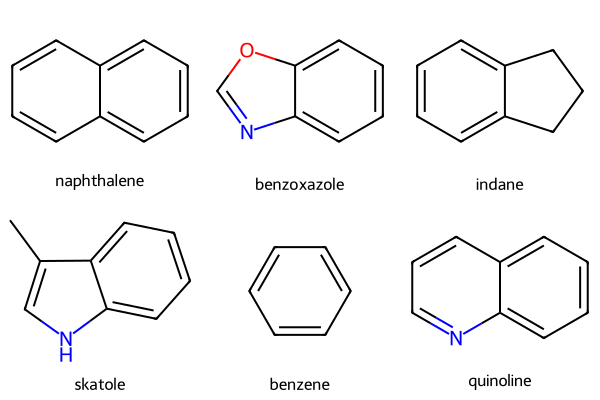

In [3]:
names = ['naphthalene', 'benzoxazole', 'indane', 'skatole', 'benzene', 'quinoline']
smiles = ['c12ccccc1cccc2', 'n1c2ccccc2oc1', 'c1ccc2c(c1)CCC2',
          'CC1=CNC2=CC=CC=C12', 'c1ccccc1', 'n1cccc2ccccc12']

# make a molecule from each SMILES string
my_molecules = [Chem.MolFromSmiles(s) for s in smiles]

Draw.MolsToGridImage(my_molecules, legends=names, useSVG=False)

`[R2]` matches an atom that is shared by two rings, so it finds fused ring systems. We check every molecule using a list comprehension, which runs the check on each molecule and collects the answers in a list (in the same order as the grid above):

In [4]:
in_two_rings = Chem.MolFromSmarts('[R2]')

[mol.HasSubstructMatch(in_two_rings) for mol in my_molecules]

[True, True, True, True, False, True]

Every molecule has a fused ring except benzene, the fifth one.

### Exercise 1: predict, then check

For each pattern below, write down which of the six molecules you think will match **before** running the cell.

- `[n]` - aromatic nitrogen
- `[r5]` - atom in a 5-membered ring
- `[CR]` - aliphatic (non-aromatic) carbon in a ring

In [5]:
patterns = ['[n]', '[r5]', '[CR]']

for p in patterns:
    query = Chem.MolFromSmarts(p)
    # zip lets us loop over the names and molecules together
    hits = [name for name, mol in zip(names, my_molecules) if mol.HasSubstructMatch(query)]
    print(p, hits)

[n] ['benzoxazole', 'skatole', 'quinoline']
[r5] ['benzoxazole', 'indane', 'skatole']
[CR] ['indane']


<details>
<summary>Solution</summary>

- `[n]`: benzoxazole, skatole and quinoline.
- `[r5]`: benzoxazole, indane and skatole.
- `[CR]`: only indane. Skatole was written with `C` and `=` in its SMILES, but RDKit recognises the ring as aromatic and turns those atoms into `c`. Skatole's methyl carbon is aliphatic but is not in a ring.

</details>

# 2. Where does it match, and how many times?

Let's switch to some familiar drugs:

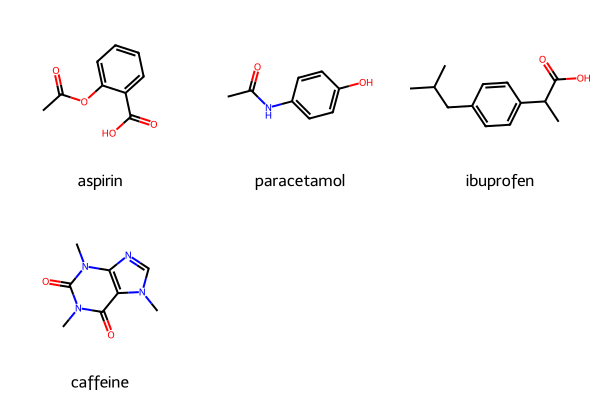

In [6]:
drug_names = ['aspirin', 'paracetamol', 'ibuprofen', 'caffeine']
drug_smiles = ['CC(=O)Oc1ccccc1C(=O)O',
               'CC(=O)Nc1ccc(O)cc1',
               'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
               'Cn1cnc2c1c(=O)n(C)c(=O)n2C']

drugs = [Chem.MolFromSmiles(s) for s in drug_smiles]

Draw.MolsToGridImage(drugs, legends=drug_names, useSVG=False)

There are three main functions for substructure searching:

- `HasSubstructMatch(pattern)` - is the pattern there? Returns `True` or `False`.
- `GetSubstructMatch(pattern)` - where is the first match? Returns the atom indices.
- `GetSubstructMatches(pattern)` - where are all the matches? Returns one set of atom indices per match.

In [7]:
aspirin = drugs[0]
carbonyl = Chem.MolFromSmarts('C=O')

print(aspirin.HasSubstructMatch(carbonyl))
print(aspirin.GetSubstructMatch(carbonyl))
print(aspirin.GetSubstructMatches(carbonyl))

True
(1, 2)
((1, 2), (10, 11))


Each match is a tuple of atom indices, in the same order as the atoms in the pattern (here: the C, then the O). Aspirin has two C=O groups, so `GetSubstructMatches` finds two matches.

To see which atoms these are, we can turn on atom index labels. After a substructure search, displaying a single molecule highlights the match automatically:

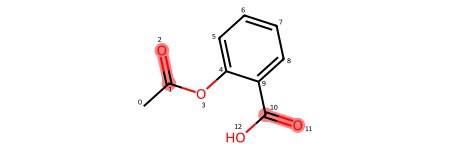

In [8]:
IPythonConsole.drawOptions.addAtomIndices = True
aspirin.GetSubstructMatches(carbonyl)
aspirin

In [9]:
# turn the labels off again
IPythonConsole.drawOptions.addAtomIndices = False

To count matches, take the length of the result:

In [10]:
len(aspirin.GetSubstructMatches(carbonyl))

2

### Exercise 2: counting

1. How many aromatic carbons does ibuprofen (`drugs[2]`) have?
2. How many oxygen atoms of any kind does aspirin have? (Hint: use the atomic number.)

In [ ]:
# Exercise 2: your code here

<details>
<summary>Solution</summary>

```python
ibuprofen = drugs[2]
print(len(ibuprofen.GetSubstructMatches(Chem.MolFromSmarts('c'))))     # 6

print(len(aspirin.GetSubstructMatches(Chem.MolFromSmarts('[#8]'))))    # 4
```

</details>

# 3. Writing specific patterns

A pattern that is too general will match things you didn't intend. Let's test `[OH]` on some small molecules:

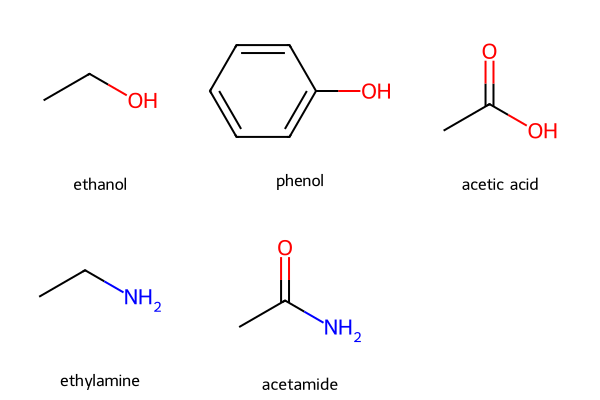

In [11]:
test_names = ['ethanol', 'phenol', 'acetic acid', 'ethylamine', 'acetamide']
test_smiles = ['CCO', 'Oc1ccccc1', 'CC(=O)O', 'CCN', 'CC(N)=O']
test_mols = [Chem.MolFromSmiles(s) for s in test_smiles]

Draw.MolsToGridImage(test_mols, legends=test_names, useSVG=False)

In [12]:
oh = Chem.MolFromSmarts('[OH]')
[mol.HasSubstructMatch(oh) for mol in test_mols]

[True, True, True, False, False]

If we wanted **alcohols**, `[OH]` is too general: it also matches phenol and acetic acid. We can be more specific by saying what the O is attached to. `[CX4][OX2H]` means "an sp3 carbon bonded to an O which has two connections, one of them a hydrogen":

In [13]:
alcohol = Chem.MolFromSmarts('[CX4][OX2H]')
[mol.HasSubstructMatch(alcohol) for mol in test_mols]

[True, False, False, False, False]

### Exercise 3: fix the pattern

Someone used `[NH2]` to search for primary amines (R-NH2).

1. Which of the test molecules does it match? Why is that a problem?
2. Write a better pattern that matches ethylamine but not acetamide.

In [ ]:
# Exercise 3: your code here

<details>
<summary>Solution</summary>

`[NH2]` matches ethylamine **and** acetamide. Acetamide is an amide, not an amine, but its N also has two hydrogens.

One fix is to require the N to be attached to an sp3 carbon:

```python
amine = Chem.MolFromSmarts('[NH2][CX4]')
[mol.HasSubstructMatch(amine) for mol in test_mols]
```

A more general version, used in the next section, is `[NX3;H2;!$(NC=O)]`. Here `;` means AND, and `!$(NC=O)` means "not an N attached to a C=O".

</details>

## Watch out for aromaticity

When RDKit reads a SMILES, it works out which rings are aromatic and stores those atoms as aromatic (`c`, `n`, `o`...), even if the SMILES was written with alternating double bonds. This affects matching:

In [14]:
benzene = Chem.MolFromSmiles('C1=CC=CC=C1')

print(benzene.HasSubstructMatch(Chem.MolFromSmarts('C1=CC=CC=C1')))  # aliphatic C: no match
print(benzene.HasSubstructMatch(Chem.MolFromSmarts('c1ccccc1')))     # aromatic c: match

False
True


Caffeine clearly has two C=O groups, but `C=O` doesn't find them. RDKit treats caffeine's rings as aromatic, so the carbonyl carbons are `c`, not `C`. Using `[#6]` (any carbon) fixes this:

In [15]:
caffeine = drugs[3]

print(len(caffeine.GetSubstructMatches(Chem.MolFromSmarts('C=O'))))
print(len(caffeine.GetSubstructMatches(Chem.MolFromSmarts('[#6]=O'))))

0
2


# 4. A functional group finder

Now we can put several patterns together. We store them in a Python **dictionary**, which maps a name (the key) to a value (here, the SMARTS string):

In [16]:
functional_groups = {
    'alcohol': '[CX4][OX2H]',
    'phenol': 'c[OX2H]',
    'carboxylic acid': '[CX3](=O)[OX2H1]',
    'ester': '[#6][CX3](=O)[OX2H0][#6]',
    'amide': '[NX3][CX3]=[OX1]',
    'primary amine': '[NX3;H2;!$(NC=O)]',
}

Parentheses are branches, just like in SMILES. For example, `[CX3](=O)[OX2H1]` is a carbon with 3 connections that has a double-bonded O and is also bonded to an OH.

This function checks a molecule against every pattern in the dictionary and returns a list of the groups it finds:

In [17]:
def find_groups(mol):
    found = []
    for group, smarts in functional_groups.items():
        pattern = Chem.MolFromSmarts(smarts)
        if mol.HasSubstructMatch(pattern):
            found.append(group)
    return found


for name, mol in zip(drug_names, drugs):
    print(name, ':', find_groups(mol))

aspirin : ['carboxylic acid', 'ester']
paracetamol : ['phenol', 'amide']
ibuprofen : ['carboxylic acid']
caffeine : []


Caffeine finds nothing, because of the aromaticity issue above: its amide-like C=O carbons are aromatic, and our amide pattern asks for `[CX3]` (aliphatic).

We can also highlight one group across all the drugs. `highlightAtomLists` needs one list of atoms per molecule:

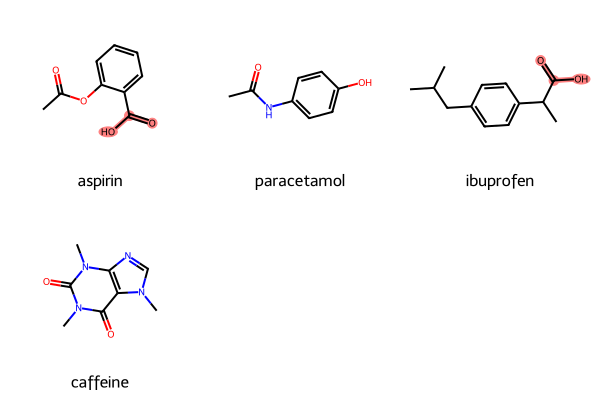

In [18]:
acid = Chem.MolFromSmarts(functional_groups['carboxylic acid'])
highlights = [mol.GetSubstructMatch(acid) for mol in drugs]

Draw.MolsToGridImage(drugs, legends=drug_names, highlightAtomLists=highlights, useSVG=False)

### Exercise 4: add your own groups

Add patterns for a **halogen** (F, Cl, Br or I) and a **nitrile** (C triple-bonded to N) to `functional_groups`, then run `find_groups` on citalopram, which contains both.

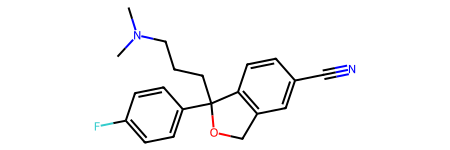

In [19]:
citalopram = Chem.MolFromSmiles('CN(C)CCCC1(OCc2cc(ccc21)C#N)c1ccc(F)cc1')

# Exercise 4: your code here

citalopram

<details>
<summary>Solution</summary>

```python
functional_groups['halogen'] = '[F,Cl,Br,I]'
functional_groups['nitrile'] = 'C#N'

find_groups(citalopram)
```

</details>

# 5. Searching a real dataset

So far we've typed our molecules in by hand. In real work you usually start from a file. The `data` folder contains `approved_drugs.sdf`, which holds 1284 approved drugs from ChEMBL.

An **SD file** (`.sdf`) is a common format for storing many molecules in one file. It is a list of mol blocks (like the ones in notebook 1), one after another. Each molecule can also have any number of named **properties** attached, such as an ID, a name or a measured value.

RDKit prints a warning whenever it finds a small problem in a file. There are a few harmless ones in this file, so we turn the warnings off to keep the output tidy:

In [27]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

To read the file, we use `Chem.SDMolSupplier`. It doesn't read everything at once. Instead, it gives us one molecule at a time as we loop over it, so we use a list comprehension to put them all in a list.

If RDKit can't read an entry, the supplier gives `None` instead of a molecule, so we skip those with `if mol is not None`. (The `../` in the file path means "go up one folder": from `notebooks` to the main folder, where `data` is.)

In [28]:
supplier = Chem.SDMolSupplier('../data/approved_drugs.sdf')
approved = [mol for mol in supplier if mol is not None]

len(approved)

1284

Each item in `approved` is an ordinary RDKit molecule, just like the ones we made from SMILES:

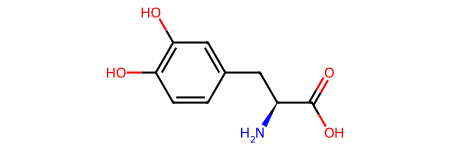

In [29]:
approved[1]

The properties from the file are stored on each molecule. `GetPropsAsDict()` shows all of them as a dictionary (property name: value):

In [30]:
approved[1].GetPropsAsDict()

{'PARENT_MOLREGNO': 112655,
 'SYNONYMS': 'Levodopa (BAN, FDA, INN, JAN, USAN, USP)',
 'DEVELOPMENT_PHASE': 4,
 'RESEARCH_CODES': nan,
 'APPLICANTS': 'Shire Development Inc; Orion Pharma; Merck Sharp And Dohme Corp; Hoffmann La Roche Inc; Valeant Pharmaceuticals International',
 'USAN_STEM': '-dopa',
 'USAN_STEM_DEFINITION': 'dopamine receptor agonists',
 'USAN_STEM_SUBSTEM': '-dopa',
 'USAN_YEAR': 1969.0,
 'FIRST_APPROVAL': 1970.0,
 'ATC_CODE': 'N04BA01',
 'ATC_CODE_DESCRIPTION': 'N04BA01 [Nervous System:Anti-Parkinson Drugs:Dopaminergic Agents:Dopa and dopa derivatives]',
 'INDICATION_CLASS': 'Antiparkinsonian',
 'SC_PATENT_NO': 'US-6500867-B1',
 'DRUG_TYPE': 'Synthetic Small Molecule',
 'RULE_OF_FIVE': 'Y',
 'FIRST_IN_CLASS': 'N',
 'CHIRALITY': 'Single Stereoisomer',
 'PRODRUG': 'N',
 'ORAL': 'Y',
 'PARENTERAL': 'N',
 'TOPICAL': 'N',
 'BLACK_BOX': 'N',
 'AVAILABILITY_TYPE': 'Prescription-only',
 'WITHDRAWN_YEAR': nan,
 'WITHDRAWN_COUNTRY': nan,
 'WITHDRAWN_REASON': nan,
 'CANONICAL_S

To get just one property, use `GetProp` with the property's name. We'll use the `name` property to label our drawings:

In [31]:
approved[1].GetProp('name')

'Levodopa '

Now we can search the whole list exactly as before. This is the same list comprehension we used on six molecules in section 1; it just runs over 1284 molecules instead:

In [32]:
acid_hits = [mol for mol in approved if mol.HasSubstructMatch(acid)]
print(len(acid_hits), 'of', len(approved), 'drugs contain a carboxylic acid')

224 of 1284 drugs contain a carboxylic acid


And draw the first 8 hits, labelled with their names:

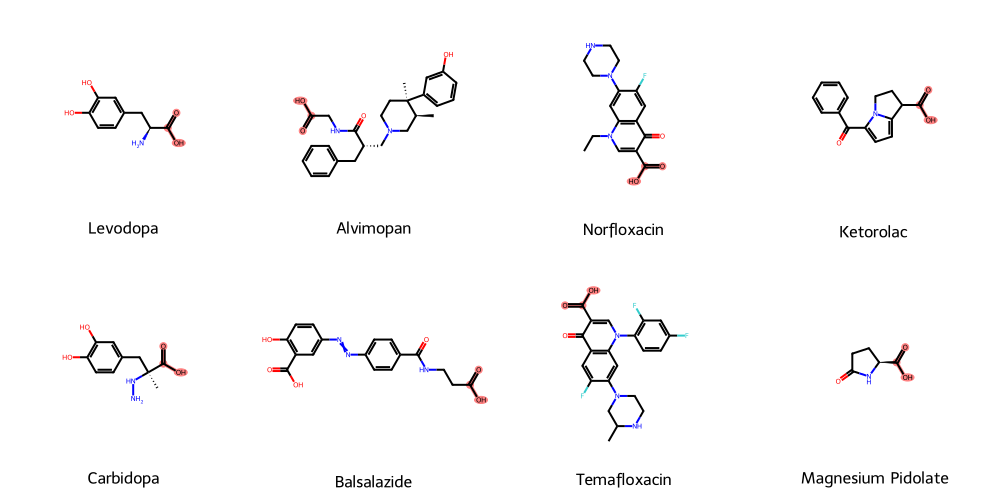

In [33]:
first_hits = acid_hits[:8]   # [:8] takes the first 8 items of the list

Draw.MolsToGridImage(first_hits,
                     legends=[mol.GetProp('name') for mol in first_hits],
                     highlightAtomLists=[mol.GetSubstructMatch(acid) for mol in first_hits],
                     molsPerRow=4,
                     subImgSize=(250, 250),
                     useSVG=False)

We can count every group in our dictionary in the same way. `sum()` adds up the True/False results, with True counting as 1:

In [34]:
for group, smarts in functional_groups.items():
    pattern = Chem.MolFromSmarts(smarts)
    count = sum(mol.HasSubstructMatch(pattern) for mol in approved)
    print(group, count)

alcohol 341
phenol 126
carboxylic acid 224
ester 181
amide 374
primary amine 240


### Exercise 5: halogens in drugs

What percentage of the approved drugs contain at least one halogen? Draw six of them with the halogen highlighted.

In [ ]:
# Exercise 5: your code here

<details>
<summary>Solution</summary>

```python
halogen = Chem.MolFromSmarts('[F,Cl,Br,I]')
halogen_hits = [mol for mol in approved if mol.HasSubstructMatch(halogen)]
print(100 * len(halogen_hits) / len(approved), '%')   # about 26 %

six = halogen_hits[:6]
Draw.MolsToGridImage(six,
                     legends=[mol.GetProp('name') for mol in six],
                     highlightAtomLists=[mol.GetSubstructMatch(halogen) for mol in six],
                     subImgSize=(250, 250),
                     useSVG=False)
```

</details>

# 6. Going further (optional)

A few more things you might find useful:

**Stereochemistry.** By default, substructure matching ignores stereochemistry. Pass `useChirality=True` to take it into account:

In [25]:
l_alanine = Chem.MolFromSmiles('C[C@@H](C(=O)O)N')
d_alanine = Chem.MolFromSmiles('C[C@H](C(=O)O)N')
query = Chem.MolFromSmarts('C[C@@H](C(=O)O)N')

print(d_alanine.HasSubstructMatch(query))                     # True: stereo ignored
print(d_alanine.HasSubstructMatch(query, useChirality=True))  # False
print(l_alanine.HasSubstructMatch(query, useChirality=True))  # True

True
False
True


**Deleting substructures.** `Chem.DeleteSubstructs` removes every match of a pattern from a molecule:

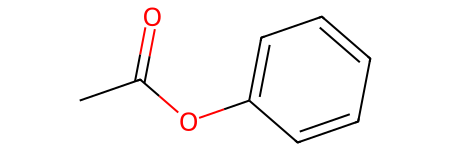

In [26]:
Chem.DeleteSubstructs(aspirin, acid)

**More examples.** Daylight has a long list of [example SMARTS patterns](https://www.daylight.com/dayhtml_tutorials/languages/smarts/smarts_examples.html) for common functional groups, which is a good place to start when writing your own.

Tutorial originally by Curt Fischer, 2016. Expanded for this workshop.